<a href="https://colab.research.google.com/github/San-B19/WeatherWise-Sanjana-Bayeeroo/blob/main-1/Weatherwise_Sanjana_Bayeeroo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyinputplus: filename=pyinputplus-0.2.12-py3-none-any.whl size=11349 sha256=f94a50d51acdadff90bef54ebaf6c32cd1a46f4ebf5175c4b36092267ef44d56
  Stored in directory: /root/.cache/pip/wheels/a3/6b/89/3bec14288af8e0729d088fb41a785e583d49e772f2529c7676
  Created wheel for pysimplevalidate: filename=pysimplevalidate-0.2.12-py3-none-any.whl size=16224 sha256=e48c60fb3334d64664b61d4b76b411db54e249434f55cf26b353b6a1a48e746b
  Stored in directory: /root/.cache/pip/wheels/fc/40/7a/4d3b2dc2e80b4b3bbda89eec94fcefd6c8bd1101cc7bb89554
  Created wheel for stdiomask: filename=stdiomask

<ipython-input-1-8850a9851271>:148: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


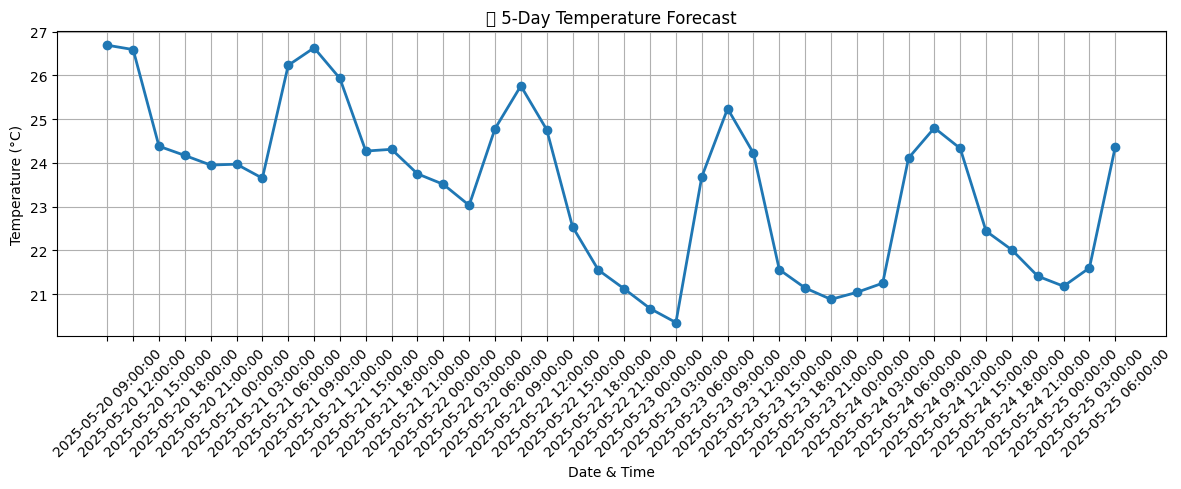

<ipython-input-1-8850a9851271>:176: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


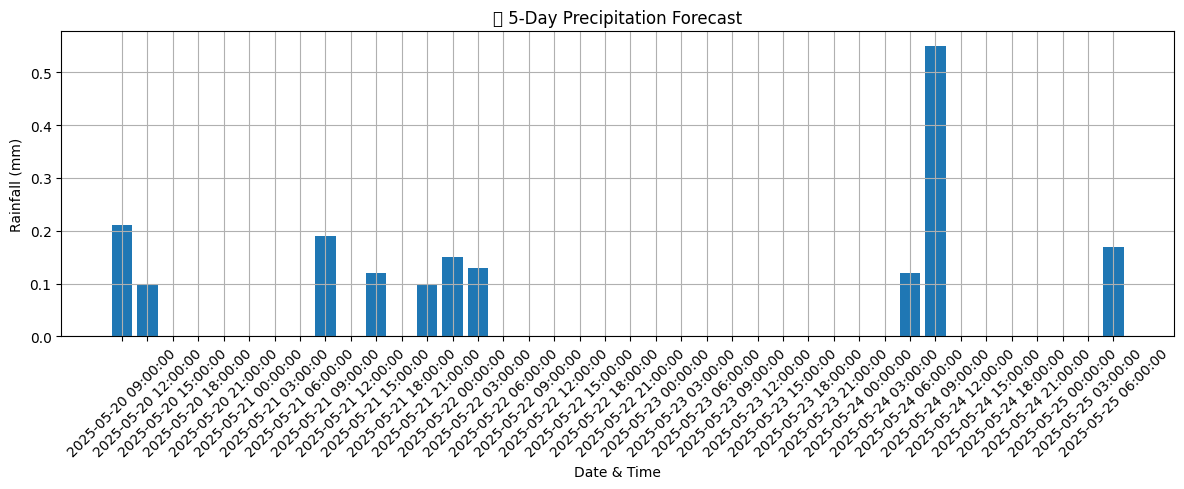


💬 Ask me a weather question (or type 'exit' to quit):
> What's the Weather in Curepipe?

📝 Response: 🌧️ The forecast for Curepipe today is light rain, 23.12°C, with 75% humidity.
📊 Do you want to see 5-day temperature and rain charts? (yes/no):
> yes


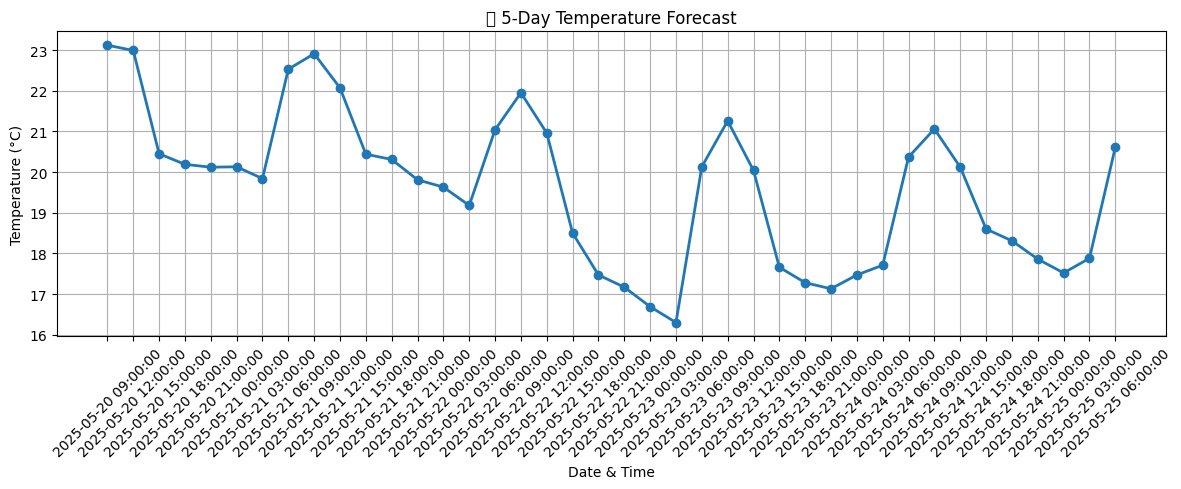

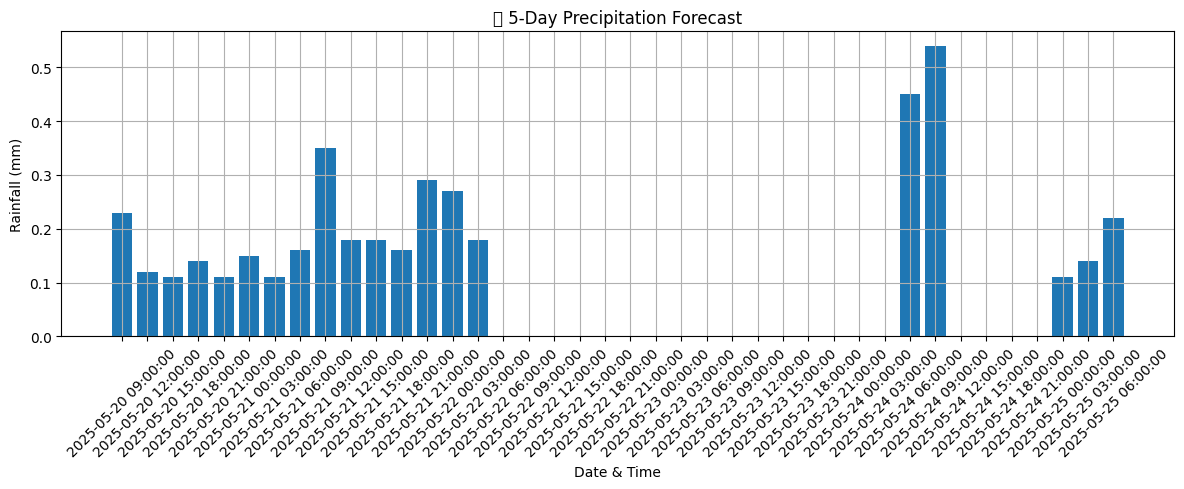


💬 Ask me a weather question (or type 'exit' to quit):
> Exit 
👋 Goodbye, stay weather-wise!


In [ ]:
# ✅ Install required packages
!pip install requests pyinputplus spacy matplotlib
!python -m spacy download en_core_web_sm

# 📚 Imports
import requests
import pyinputplus as pyip
import spacy
import matplotlib.pyplot as plt
import os
import datetime

# 🔐 Prompt for OpenWeatherMap API Key
if not os.environ.get("OPENWEATHER_API_KEY"):
    api_key_input = pyip.inputStr("🔑 Please enter your OpenWeatherMap API Key:\n> ")
    os.environ["OPENWEATHER_API_KEY"] = api_key_input

# 🌐 Load spaCy model
nlp = spacy.load("en_core_web_sm")

# -----------------------------------------------
# 1. Get Weather Data
# -----------------------------------------------
def get_weather_data(location, forecast_days=5):
    """
    Retrieve weather data from OpenWeatherMap API.
    """
    api_key = os.environ.get("OPENWEATHER_API_KEY")
    if not api_key:
        print("❗ Error: API key not found.")
        return None

    try:
        url = f"http://api.openweathermap.org/data/2.5/forecast?q={location}&appid={api_key}&units=metric"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json()
    except requests.RequestException as e:
        print(f"❗ API Error: {e}")
        return None

# -----------------------------------------------
# 2. Parse Natural Language Weather Questions
# -----------------------------------------------
def parse_weather_question(question):
    """
    Parse user question to extract location, date, and weather attribute.
    """
    doc = nlp(question)
    location = None
    date = None
    attribute = None

    for ent in doc.ents:
        if ent.label_ == "GPE":
            location = ent.text

    q = question.lower()
    if "today" in q:
        date = "today"
    elif "tomorrow" in q:
        date = "tomorrow"
    elif "weekend" in q:
        date = "weekend"

    keywords = {
        "temperature": ["temperature", "hot", "cold", "warm", "chilly"],
        "rain": ["rain", "raining", "rainfall", "umbrella"],
        "humidity": ["humidity", "humid"],
        "wind": ["wind", "breeze", "windy"],
        "condition": ["weather", "forecast", "conditions"]
    }

    for key, words in keywords.items():
        for word in words:
            if word in q:
                attribute = key
                break

    return {"location": location, "date": date, "attribute": attribute}

# -----------------------------------------------
# 3. Generate Friendly Weather Response
# -----------------------------------------------
def generate_weather_response(parsed, weather_data):
    city = parsed.get("location")
    date = parsed.get("date")
    attribute = parsed.get("attribute")

    if not city or not weather_data:
        return "❗ Sorry, I couldn't retrieve weather data."

    # Choose forecast time based on date
    if date == "today":
        index = 0
    elif date == "tomorrow":
        index = 8  # 24 hours ahead (3-hour intervals)
    elif date == "weekend":
        index = 16  # Approx. 2–3 days ahead
    else:
        index = 0

    try:
        forecast = weather_data["list"][index]
        condition = forecast["weather"][0]["description"]
        temp = forecast["main"]["temp"]
        humidity = forecast["main"]["humidity"]
        wind = forecast["wind"]["speed"]
        emoji = "☀️" if "clear" in condition else "🌧️" if "rain" in condition else "☁️"

        # Tailored responses
        if attribute == "temperature":
            return f"{emoji} It will be around {temp}°C in {city} {date or 'today'}."
        elif attribute == "rain":
            rain = forecast.get("rain", {}).get("3h", 0)
            return f"{emoji} Expect about {rain}mm of rain in {city} {date or 'today'}."
        elif attribute == "humidity":
            return f"{emoji} The humidity in {city} {date or 'today'} will be around {humidity}%."
        elif attribute == "wind":
            return f"{emoji} Wind speeds will reach {wind} m/s in {city}."
        else:
            return f"{emoji} The forecast for {city} {date or 'today'} is {condition}, {temp}°C, with {humidity}% humidity."
    except Exception as e:
        return f"⚠️ Could not generate weather summary due to: {e}"

# -----------------------------------------------
# 4. Visualisation: Temperature Forecast (5 Days)
# -----------------------------------------------
def create_temperature_visualisation(weather_data, output_type='display'):
    """
    Plot temperature for 5 days (3-hour intervals).
    """
    temps = [entry['main']['temp'] for entry in weather_data['list']]
    times = [entry['dt_txt'] for entry in weather_data['list']]

    plt.figure(figsize=(12, 5))
    plt.plot(times, temps, marker='o', linestyle='-', linewidth=2)
    plt.title("🌡️ 5-Day Temperature Forecast")
    plt.xlabel("Date & Time")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    if output_type == 'figure':
        return plt
    else:
        plt.show()

# -----------------------------------------------
# 5. Visualisation: Precipitation Forecast (5 Days)
# -----------------------------------------------
def create_precipitation_visualisation(weather_data, output_type='display'):
    """
    Plot rainfall for 5 days (3-hour intervals).
    """
    rain_values = []
    times = []
    for entry in weather_data['list']:
        rain = entry.get('rain', {}).get('3h', 0)
        rain_values.append(rain)
        times.append(entry['dt_txt'])

    plt.figure(figsize=(12, 5))
    plt.bar(times, rain_values)
    plt.title("🌧️ 5-Day Precipitation Forecast")
    plt.xlabel("Date & Time")
    plt.ylabel("Rainfall (mm)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    if output_type == 'figure':
        return plt
    else:
        plt.show()

# -----------------------------------------------
# 6. Main Application Chat Loop
# -----------------------------------------------
def main():
    print("🌦️ Welcome to WeatherWise – Your Intelligent Weather Advisor 🌤️")
    while True:
        query = pyip.inputStr("\n💬 Ask me a weather question (or type 'exit' to quit):\n> ")
        if query.lower() in ["exit", "quit"]:
            print("👋 Goodbye, stay weather-wise!")
            break

        parsed = parse_weather_question(query)
        if not parsed["location"]:
            print("❗ I couldn't detect a location. Please try again.")
            continue

        data = get_weather_data(parsed["location"])
        response = generate_weather_response(parsed, data)
        print("\n📝 Response:", response)

        show_viz = pyip.inputYesNo("📊 Do you want to see 5-day temperature and rain charts? (yes/no):\n> ")
        if show_viz == "yes":
            create_temperature_visualisation(data)
            create_precipitation_visualisation(data)

# -----------------------------------------------
# Run the Application
# -----------------------------------------------
main()
